Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Styling the Theme

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

Loading data sets 

In [ ]:
data_path = "../Data"

demo = pd.read_csv(f"{data_path}/df_final_demo_cleaned.csv")
exp = pd.read_csv(f"{data_path}/df_final_experiment_clients_cleaned.csv")
web = pd.read_csv(f"{data_path}/final_test_data.csv")
funnel = pd.read_csv(f"{data_path}/web_funnel_sorted.csv")

print("demo:", demo.shape)
print("exp:", exp.shape)
print("web:", web.shape)
print("funnel:", funnel.shape)

demo: (70609, 9)
exp: (70609, 2)
web: (443897, 7)
funnel: (744641, 6)


Quick Confirmation

In [9]:
for name, df in [("demo", demo), ("exp", exp), ("web", web)]:
    print(f"\n── {name} ──")
    print(df.shape)
    print(df.dtypes)
    print(df.head(2))


── demo ──
(70609, 9)
client_id                 int64
tenure_years            float64
tenure_months           float64
age                     float64
gender                      str
num_accts               float64
balance                 float64
calls_last_6_months     float64
logons_last_6_months    float64
dtype: object
   client_id  tenure_years  tenure_months   age gender  num_accts   balance  \
0     836976           6.0           73.0  60.5      U        2.0   45105.3   
1    2304905           7.0           94.0  58.0      U        2.0  110860.3   

   calls_last_6_months  logons_last_6_months  
0                  6.0                   9.0  
1                  6.0                   9.0  

── exp ──
(70609, 2)
client_id     int64
group_test      str
dtype: object
   client_id group_test
0    9988021       test
1    8320017       test

── web ──
(443897, 7)
client_id       int64
visitor_id        str
visit_id          str
process_step      str
date_time         str
source         

Merging Demo + Experiment
figuring  out which clients are in Test vs Control 

In [11]:
print(demo.columns)
print(exp.columns)
print(df.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months'],
      dtype='str')
Index(['client_id', 'group_test'], dtype='str')
Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test'],
      dtype='str')


In [13]:
df = demo.merge(exp, on="client_id", how="inner")

print(f"Merged shape: {df.shape}")
print(df["group_test"].value_counts())

Merged shape: (70609, 10)
group_test
test       26968
control    23532
Name: count, dtype: int64


DEMOGRAPHICS: figuring  out who the primary clients are ?

Checking Colums

In [15]:
print(df.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test'],
      dtype='str')


 Age Distribution

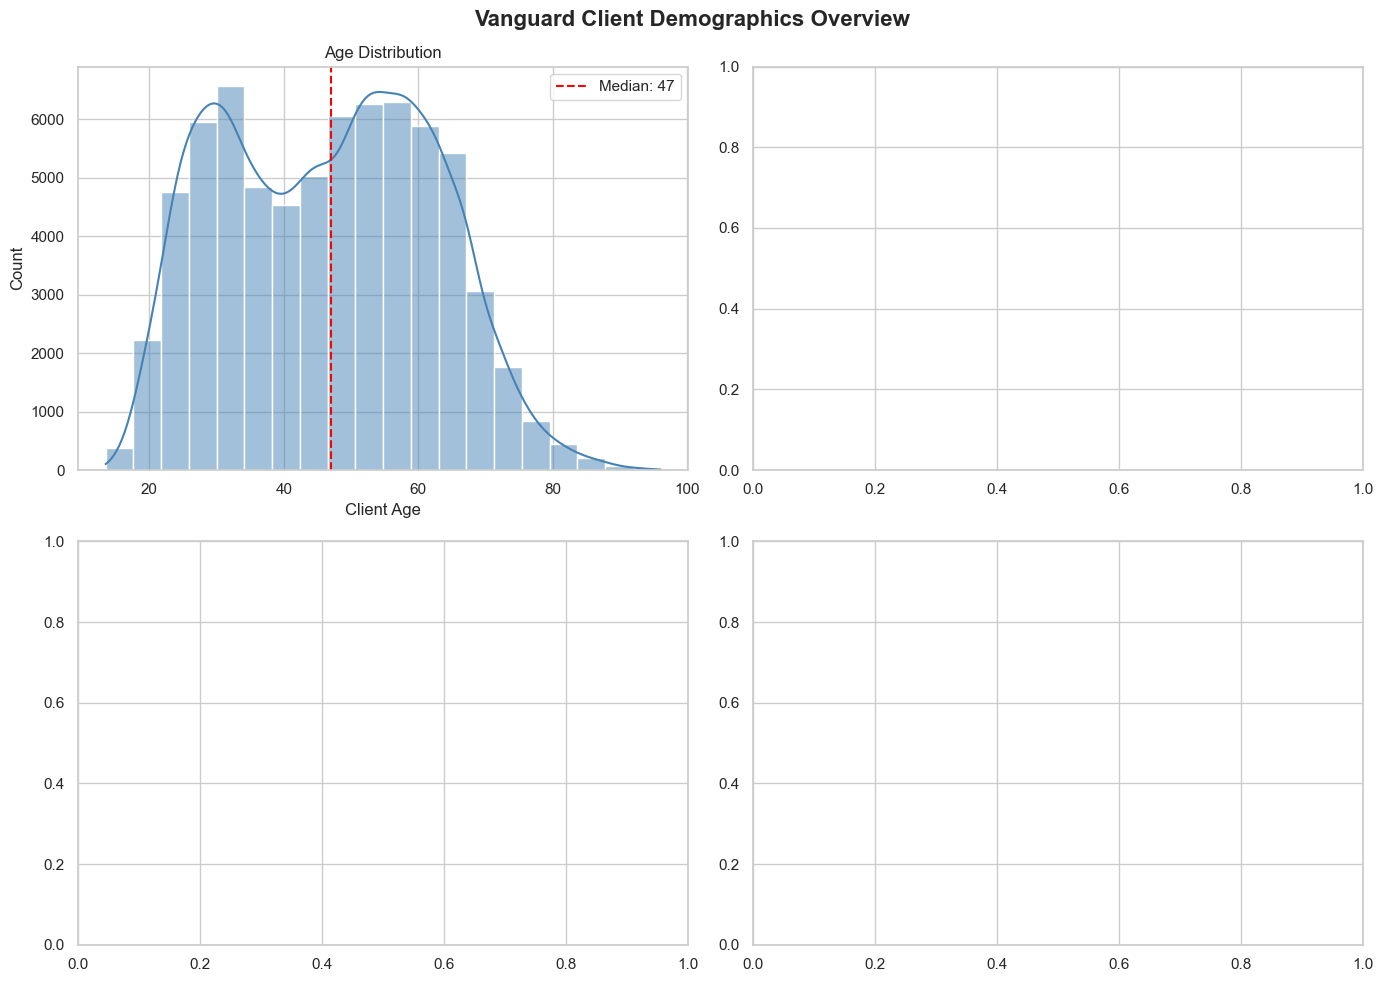

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Client Age")
axes[0, 0].axvline(df["age"].median(), color="red", linestyle="--",
                   label=f"Median: {df['age'].median():.0f}")
axes[0, 0].legend()

plt.tight_layout()
plt.show()

Gender Distribution

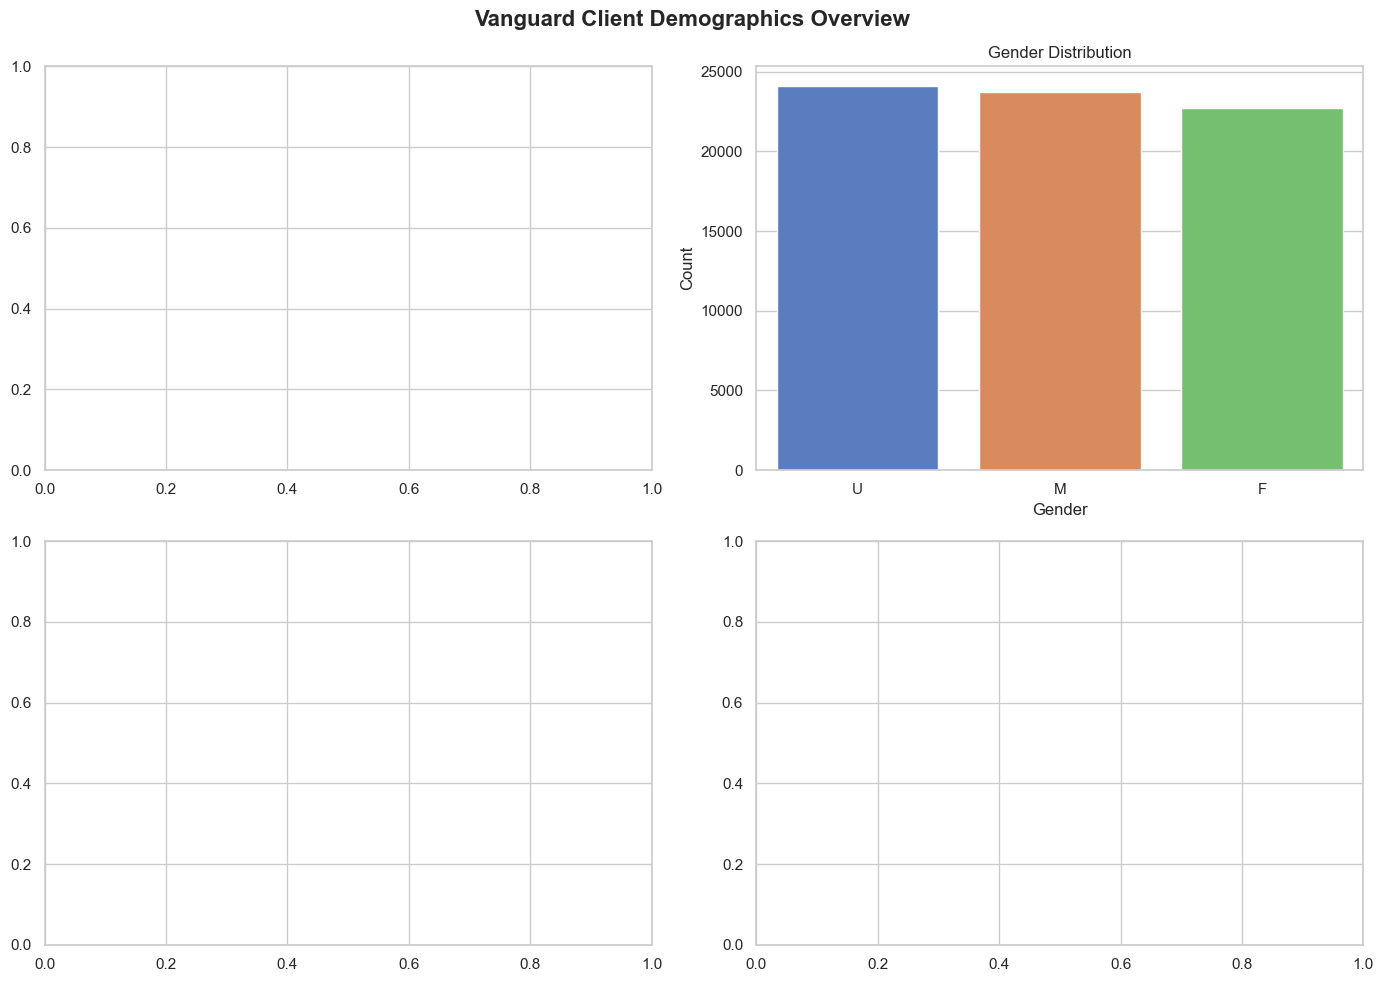

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    ax=axes[0, 1],
    hue=gender_counts.index,
    palette="muted",
    legend=False
)

axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Count")

plt.tight_layout()

plt.show()

Account Balance Distirbution

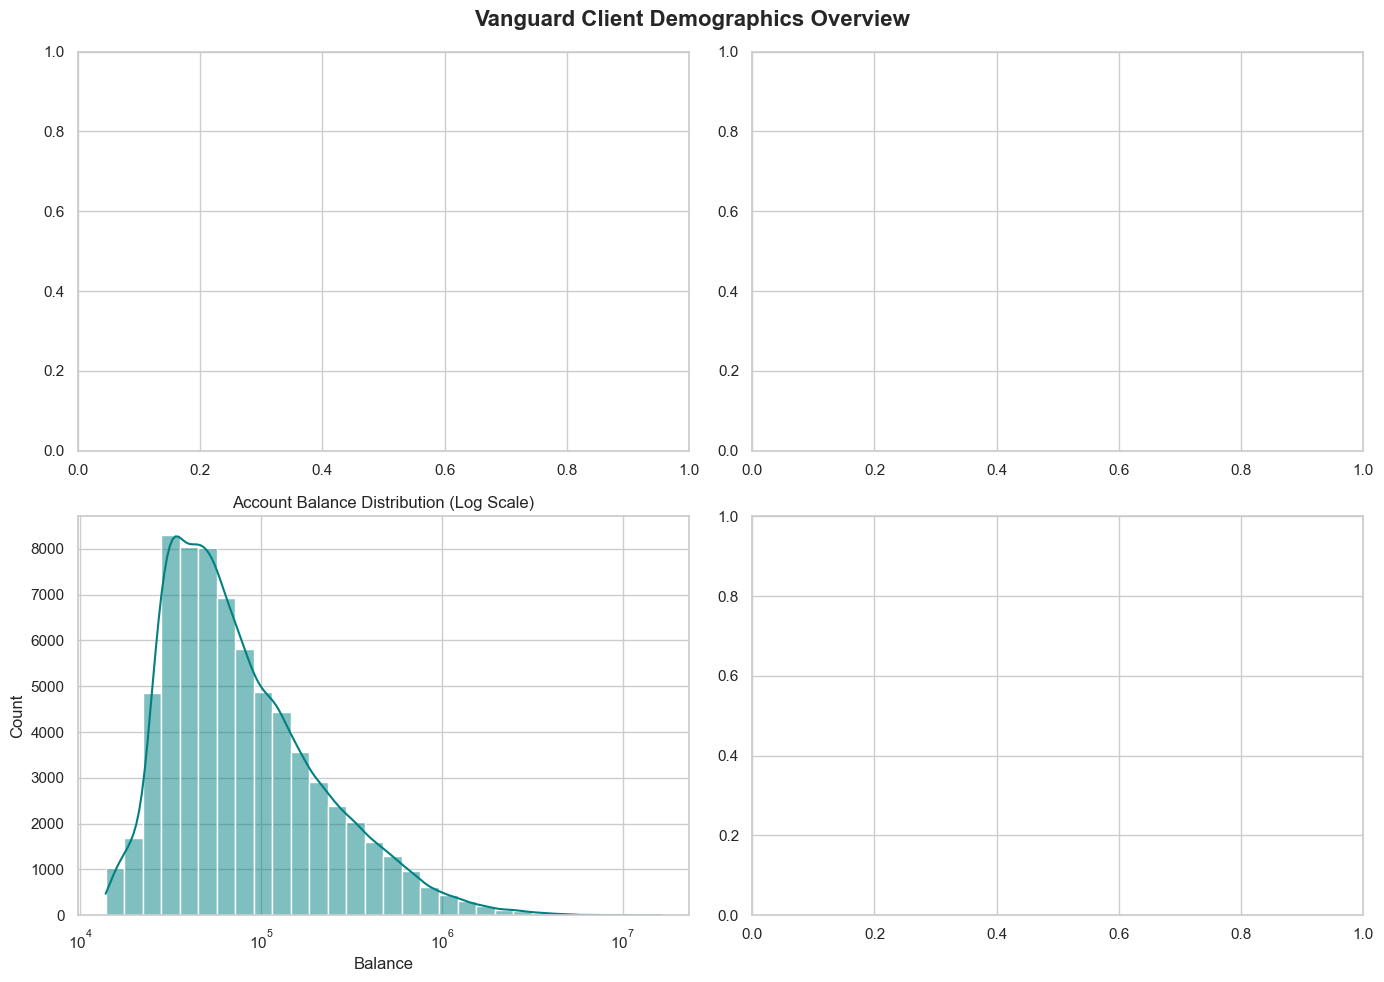

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

sns.histplot(
    df["balance"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color="teal",
    log_scale=(True, False)
)

axes[1, 0].set_title("Account Balance Distribution (Log Scale)")
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_ylabel("Count")

plt.tight_layout()
plt.show()

Number of Accoutns Distribution

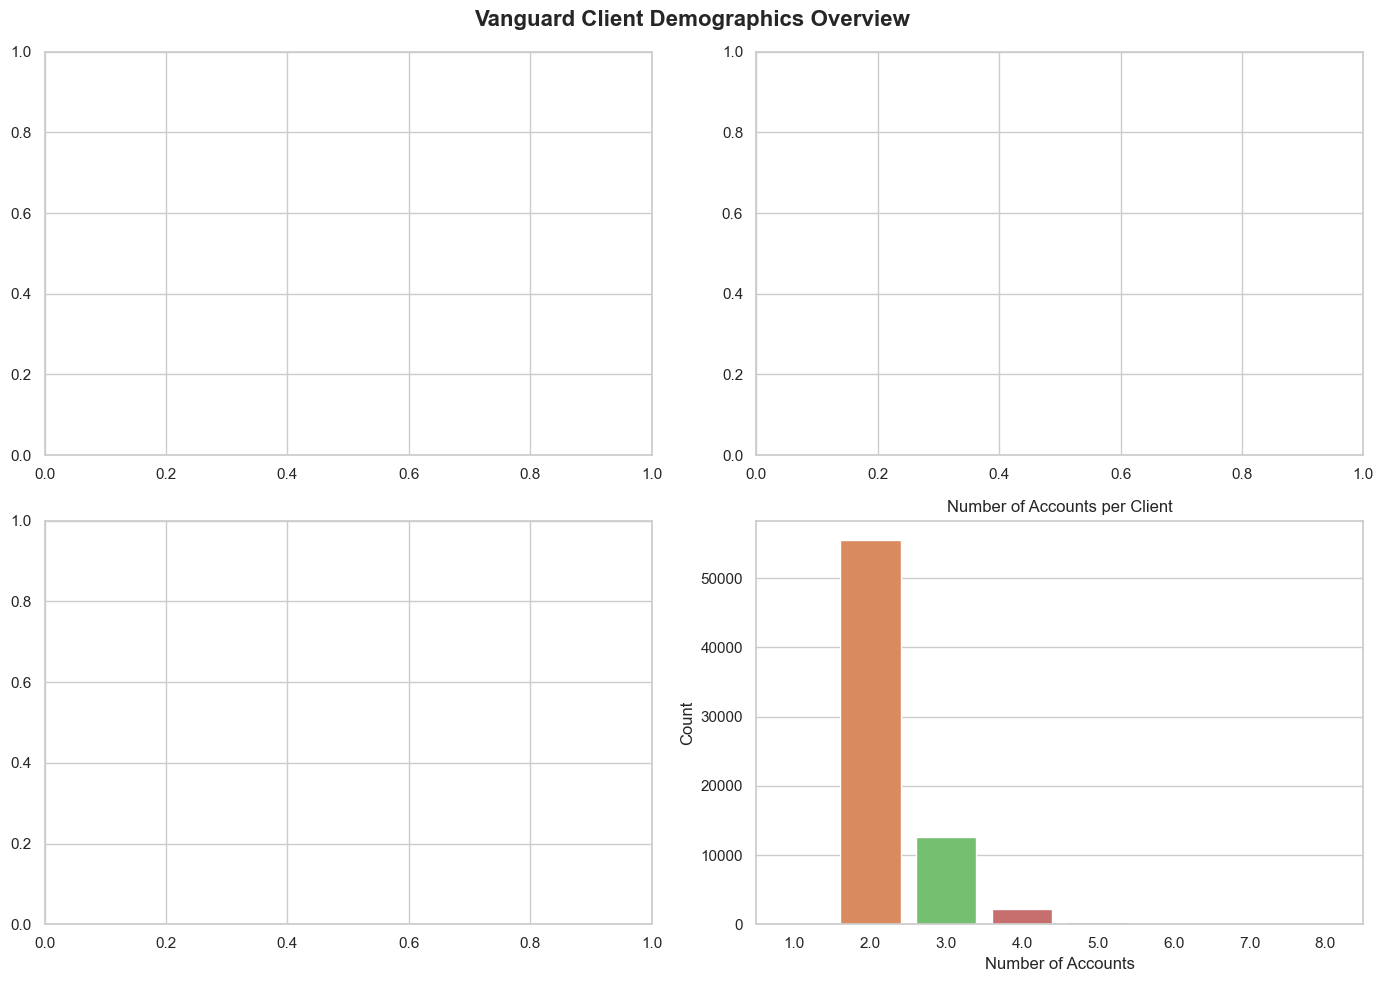

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

acct_counts = df["num_accts"].value_counts().sort_index()

sns.barplot(
    x=acct_counts.index,
    y=acct_counts.values,
    ax=axes[1, 1],
    hue=acct_counts.index,
    palette="muted",
    legend=False
)

axes[1, 1].set_title("Number of Accounts per Client")
axes[1, 1].set_xlabel("Number of Accounts")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

All elements Together 

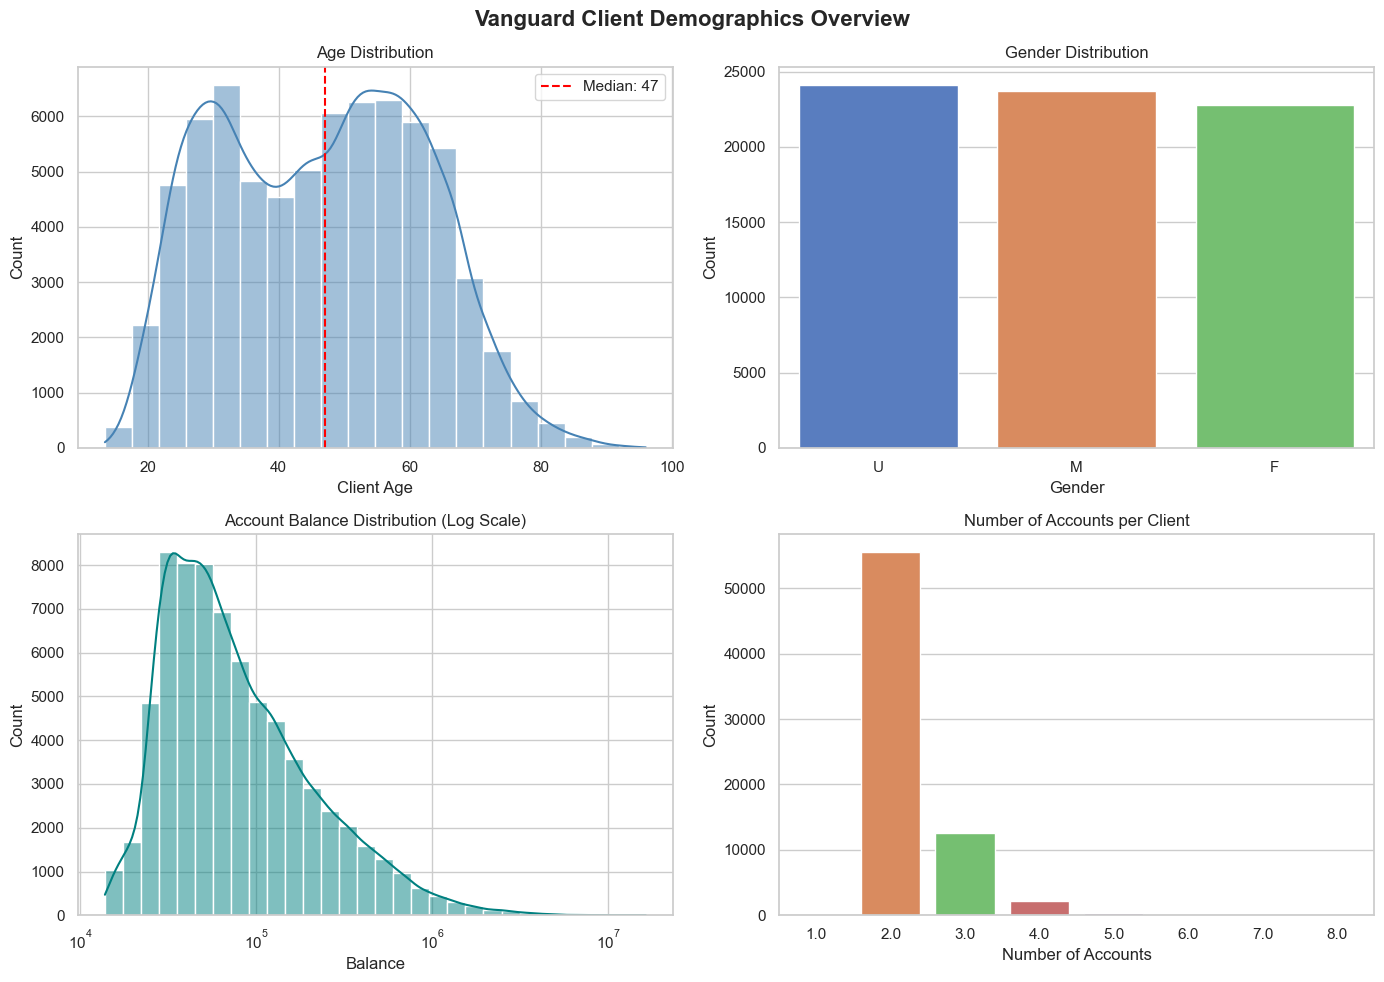

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vanguard Client Demographics Overview", fontsize=16, fontweight="bold")

# Age Distribution
sns.histplot(
    df["age"].dropna(),
    bins=20,
    kde=True,
    ax=axes[0, 0],
    color="steelblue"
)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Client Age")
axes[0, 0].axvline(
    df["age"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df['age'].median():.0f}"
)
axes[0, 0].legend()

# Gender Distribution
gender_counts = df["gender"].value_counts()
sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    ax=axes[0, 1],
    hue=gender_counts.index,
    palette="muted",
    legend=False
)
axes[0, 1].set_title("Gender Distribution")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Count")

# Account Balance Distribution
sns.histplot(
    df["balance"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color="teal",
    log_scale=(True, False)
)
axes[1, 0].set_title("Account Balance Distribution (Log Scale)")
axes[1, 0].set_xlabel("Balance")
axes[1, 0].set_ylabel("Count")

# Number of Accounts
acct_counts = df["num_accts"].value_counts().sort_index()
sns.barplot(
    x=acct_counts.index,
    y=acct_counts.values,
    ax=axes[1, 1],
    hue=acct_counts.index,
    palette="muted",
    legend=False
)
axes[1, 1].set_title("Number of Accounts per Client")
axes[1, 1].set_xlabel("Number of Accounts")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../visualizations/demographics_overview.png", dpi=150, bbox_inches="tight")

plt.show()

Statistics Summary 

In [31]:
print("=== KEY DEMOGRAPHIC STATS ===")
print(f"Median Age:         {df['age'].median():.1f} years")
print(f"Mean Age:           {df['age'].mean():.1f} years")
print(f"Median Balance:     ${df['balance'].median():,.0f}")
print(f"Most common # accts: {df['num_accts'].mode()[0]}")
print(f"\nGender breakdown:\n{df['gender'].value_counts(normalize=True).mul(100).round(1)}")

=== KEY DEMOGRAPHIC STATS ===
Median Age:         47.0 years
Mean Age:           46.4 years
Median Balance:     $63,333
Most common # accts: 2.0

Gender breakdown:
gender
U    34.2
M    33.6
F    32.2
Name: proportion, dtype: float64


YOUNGER OR OLDER? NEW OR LONG-STANDING?

C:\Users\Desmond\AppData\Local\Temp\ipykernel_7700\77259254.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


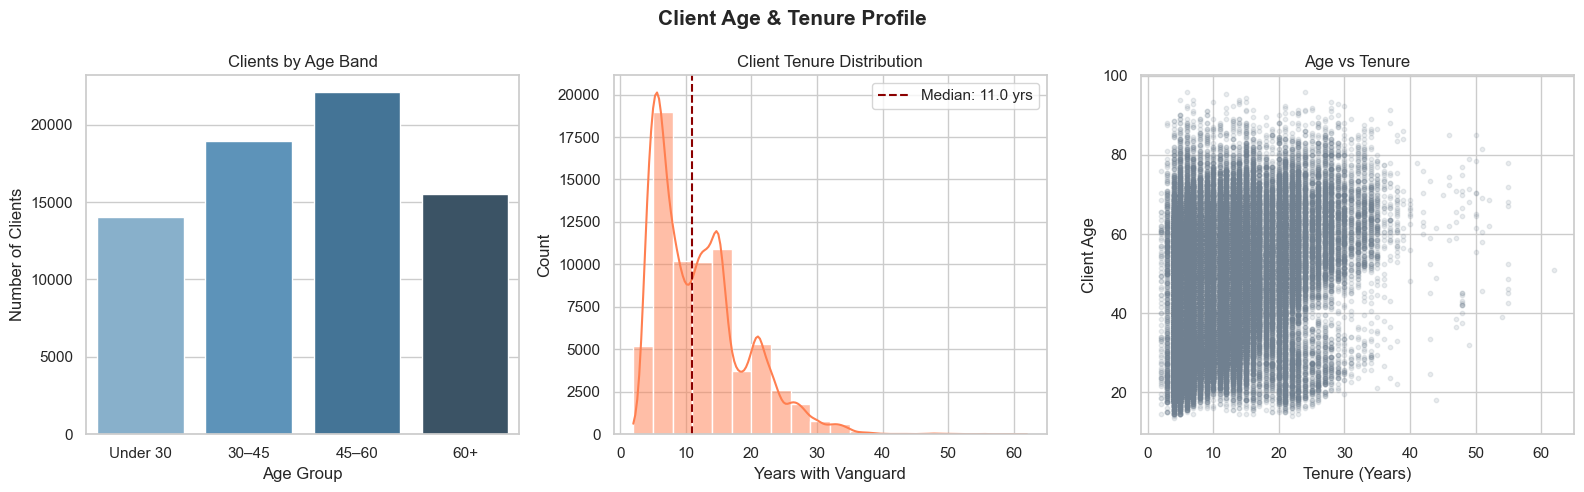

=== AGE & TENURE SUMMARY ===
Median Tenure:  11.0 years
Mean Tenure:    12.1 years

Age band breakdown:
age_band
Under 30    19.9
30–45       26.9
45–60       31.3
60+         22.0
Name: proportion, dtype: float64


In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("../visualizations", exist_ok=True)

# Age Bands
df["age_band"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Under 30", "30–45", "45–60", "60+"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Client Age & Tenure Profile", fontsize=15, fontweight="bold")

# Age bands bar chart
age_band_counts = df["age_band"].value_counts().sort_index()
sns.barplot(
    x=age_band_counts.index,
    y=age_band_counts.values,
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Clients by Age Band")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Clients")

# Tenure distribution
sns.histplot(
    df["tenure_years"].dropna(),
    bins=20,
    kde=True,
    ax=axes[1],
    color="coral"
)
axes[1].set_title("Client Tenure Distribution")
axes[1].set_xlabel("Years with Vanguard")
axes[1].axvline(
    df["tenure_years"].median(),
    color="darkred",
    linestyle="--",
    label=f"Median: {df['tenure_years'].median():.1f} yrs"
)
axes[1].legend()

# Age vs Tenure scatter
axes[2].scatter(
    df["tenure_years"],
    df["age"],
    alpha=0.15,
    color="slategray",
    s=10
)
axes[2].set_title("Age vs Tenure")
axes[2].set_xlabel("Tenure (Years)")
axes[2].set_ylabel("Client Age")

plt.tight_layout()
plt.savefig("../visualizations/age_tenure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

# Key Numbers
print("=== AGE & TENURE SUMMARY ===")
print(f"Median Tenure:  {df['tenure_years'].median():.1f} years")
print(f"Mean Tenure:    {df['tenure_years'].mean():.1f} years")
print(f"\nAge band breakdown:\n{df['age_band'].value_counts(normalize=True).mul(100).round(1).sort_index()}")

CLIENT BEHAVIOUR ANALYSIS


Process Step Drop-off Funnel : Defining  correct step order

C:\Users\Desmond\AppData\Local\Temp\ipykernel_7700\2289447309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_counts.index, y=funnel_counts.values, ax=axes[0], palette="viridis")
C:\Users\Desmond\AppData\Local\Temp\ipykernel_7700\2289447309.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=drop_off.index[1:], y=drop_off.values[1:], ax=axes[1], palette="Reds_d")


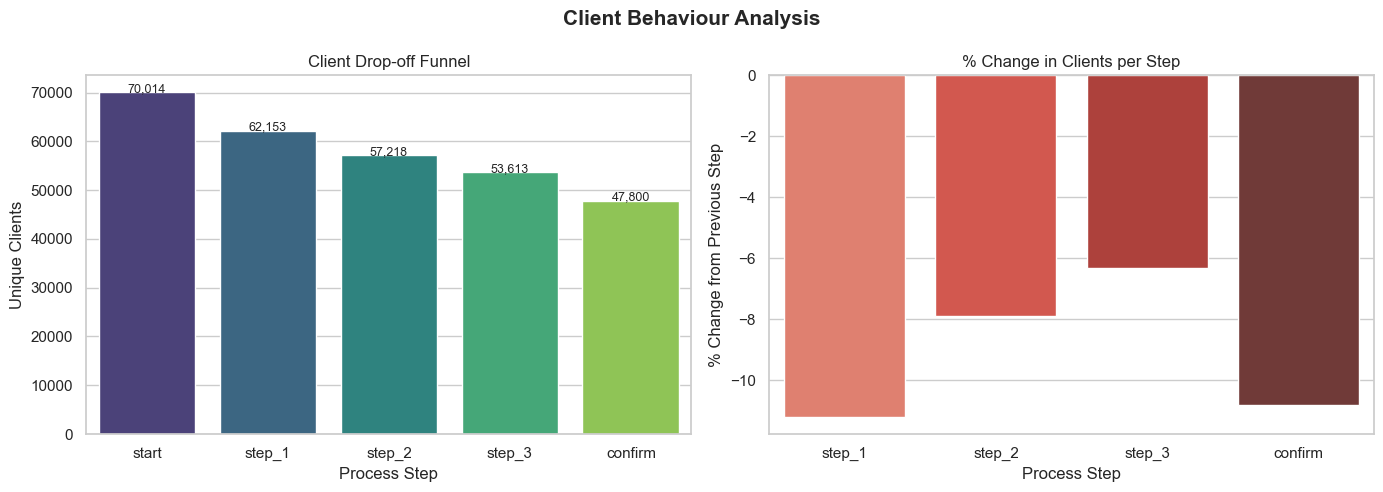

In [35]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# Count unique clients reaching each step
funnel_counts = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Client Behaviour Analysis", fontsize=15, fontweight="bold")

# Funnel bar chart
sns.barplot(x=funnel_counts.index, y=funnel_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Client Drop-off Funnel")
axes[0].set_xlabel("Process Step")
axes[0].set_ylabel("Unique Clients")
for i, v in enumerate(funnel_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

# Drop-off rate between steps
drop_off = funnel_counts.pct_change().mul(100).round(1)
sns.barplot(x=drop_off.index[1:], y=drop_off.values[1:], ax=axes[1], palette="Reds_d")
axes[1].set_title("% Change in Clients per Step")
axes[1].set_xlabel("Process Step")
axes[1].set_ylabel("% Change from Previous Step")

plt.tight_layout()
plt.savefig("../visualizations/client_behaviour_funnel.png", dpi=150)
plt.show()

Engagement vs Completion

In [37]:
print(df.columns)
print(web.columns)

Index(['client_id', 'tenure_years', 'tenure_months', 'age', 'gender',
       'num_accts', 'balance', 'calls_last_6_months', 'logons_last_6_months',
       'group_test', 'age_band', 'completed'],
      dtype='str')
Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'source', 'group_test'],
      dtype='str')


C:\Users\Desmond\AppData\Local\Temp\ipykernel_7700\565898970.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Desmond\AppData\Local\Temp\ipykernel_7700\565898970.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


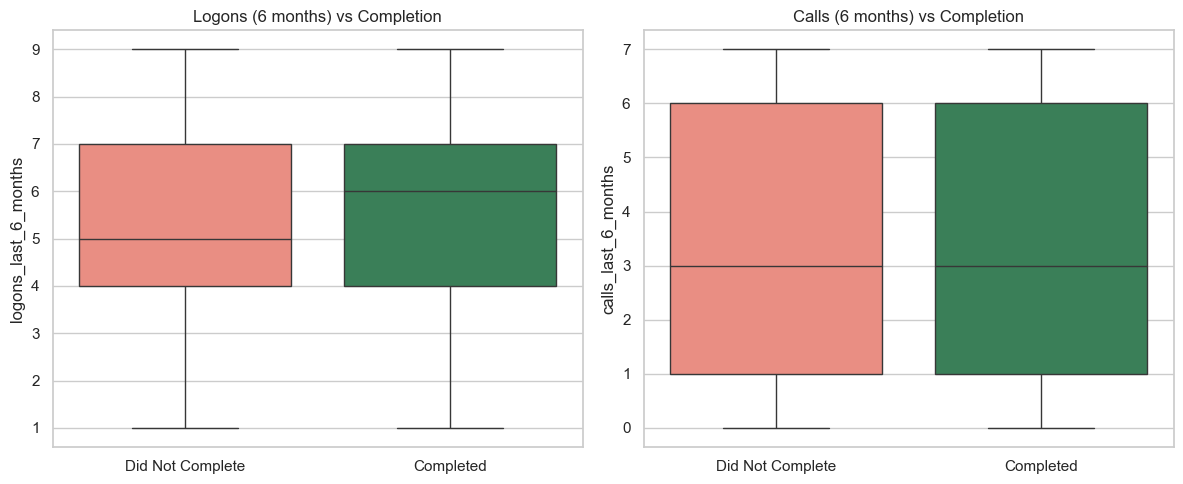

=== COMPLETION RATE ===
Overall completion rate: 67.7%

Completion by variation:
group_test
control    65.6
test       69.3
Name: completed, dtype: float64


In [38]:
import os

os.makedirs("../visualizations", exist_ok=True)

# Clients who reached confirm page
completers = web.loc[web["process_step"] == "confirm", "client_id"].unique()
df["completed"] = df["client_id"].isin(completers).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logons vs completion
sns.boxplot(
    x="completed",
    y="logons_last_6_months",
    data=df,
    ax=axes[0],
    palette=["salmon", "seagreen"]
)
axes[0].set_title("Logons (6 months) vs Completion")
axes[0].set_xlabel("")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Did Not Complete", "Completed"])

# Calls vs completion
sns.boxplot(
    x="completed",
    y="calls_last_6_months",
    data=df,
    ax=axes[1],
    palette=["salmon", "seagreen"]
)
axes[1].set_title("Calls (6 months) vs Completion")
axes[1].set_xlabel("")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Did Not Complete", "Completed"])

plt.tight_layout()
plt.savefig("../visualizations/engagement_vs_completion.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== COMPLETION RATE ===")
print(f"Overall completion rate: {df['completed'].mean() * 100:.1f}%")
print(f"\nCompletion by variation:\n{df.groupby('group_test')['completed'].mean().mul(100).round(1)}")

Key Findings 

Who are the primary clients using this online process?

The typical Vanguard client is **middle-aged (median 47 years)**, holds **2 accounts**,
and carries a **median balance of $63,333**. Gender is approximately evenly split.
This profile suggests an established, mid-career investor.

Are the primary clients younger or older, new or long-standing?

The largest client segment is **45–60 years old (31.3%)**.
Over **53% of clients are aged 45 or above**.
The median tenure is **11 years**, confirming these are predominantly
**long-standing, loyal clients** — not new users.

Does the new design make business sense ?

The Test group completed the process at **69.3%** vs **65.6%** for Control
a **+3.7 percentage point uplift**. 